In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('BP Stock.xlsx')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-02-14,359.958939,363.655015,355.484741,355.484741,26586551,0.0,0
1,2020-02-17,359.064123,361.359567,357.041003,358.713959,19270109,0.0,0
2,2020-02-18,357.002027,359.102964,350.154569,355.990479,40009436,0.0,0
3,2020-02-19,360.270227,361.398513,356.340724,360.114594,35014591,0.0,0
4,2020-02-20,363.382680,365.381674,359.647707,362.760193,31502740,0.0,0


In [4]:
#Converting Date into Datetime
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
#Descriptive Statistics
df.describe()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1263,1263.000000,1263.000000,1263.000000,1263.000000,1.263000e+03,1263.000000,1263.0
mean,2022-08-16 05:35:12.114014464,357.512776,362.657804,352.976267,357.513656,5.167019e+07,7.641512,0.0
min,2020-02-14 00:00:00,155.144123,157.687200,152.682035,156.666733,4.659383e+06,0.000000,0.0
25%,2021-05-17 12:00:00,260.802324,265.669256,257.077616,261.125351,3.355545e+07,0.000000,0.0
50%,2022-08-16 00:00:00,379.049988,384.100006,375.149994,379.250000,4.503910e+07,0.000000,0.0
75%,2023-11-15 12:00:00,441.477047,445.847609,436.205339,440.354401,6.206207e+07,0.000000,0.0
max,2025-02-14 00:00:00,523.125413,526.401935,517.882915,522.376465,2.574570e+08,834.210000,0.0
std,NaN,95.550021,95.732749,95.290133,95.462479,2.756570e+07,63.410587,0.0


In [7]:
#Checking Null Values
print(df.isnull().sum())

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


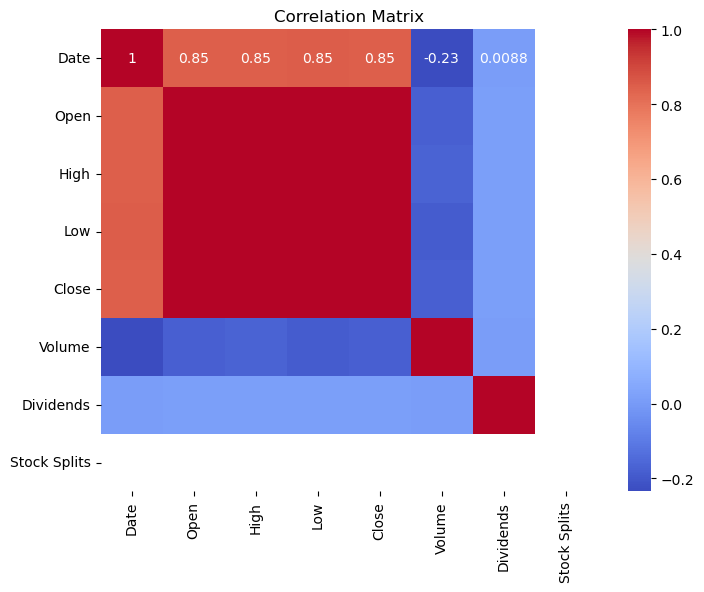

In [8]:
#Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

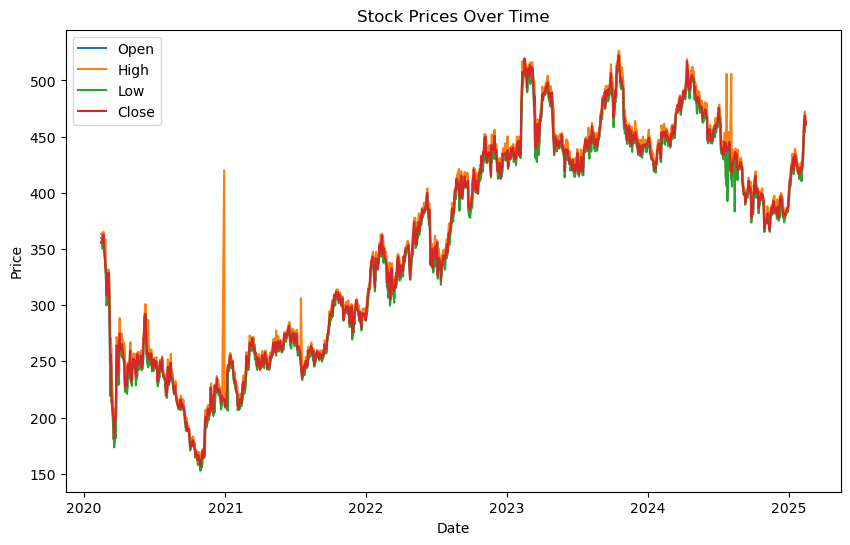

In [9]:
#Time series plot for stock prices
plt.figure(figsize=(10, 6))
for column in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df['Date'], df[column], label=column)
plt.legend()
plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

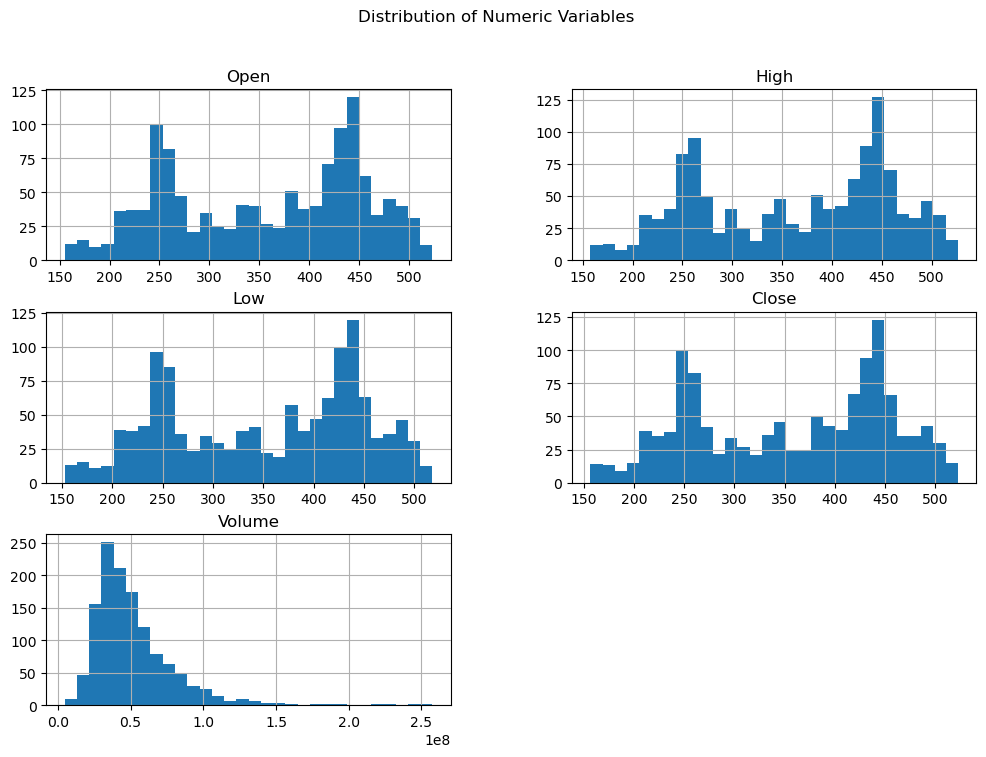

In [10]:
#Distribution Plots of Numeric Variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle('Distribution of Numeric Variables')
plt.show()

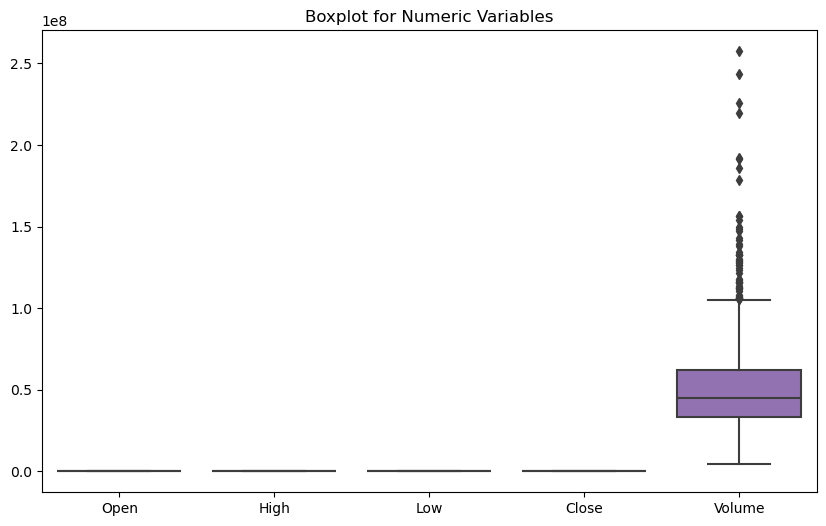

In [11]:
#Box Plot for Outlier Detection
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot for Numeric Variables')
plt.show()

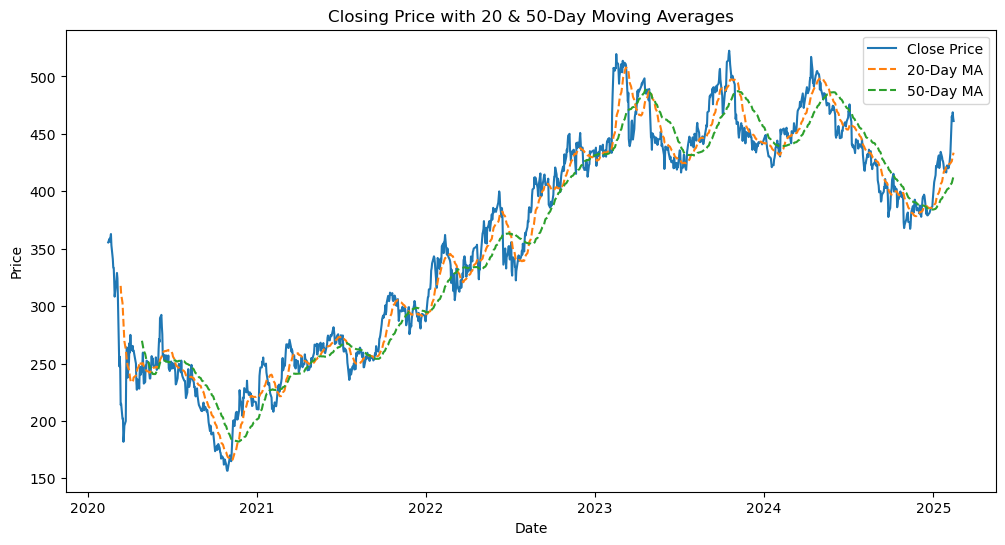

In [12]:
df.set_index('Date', inplace=True)

#Moving Averages
df['20_MA'] = df['Close'].rolling(window=20).mean()
df['50_MA'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['20_MA'], label='20-Day MA', linestyle='--')
plt.plot(df['50_MA'], label='50-Day MA', linestyle='--')
plt.legend()
plt.title('Closing Price with 20 & 50-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

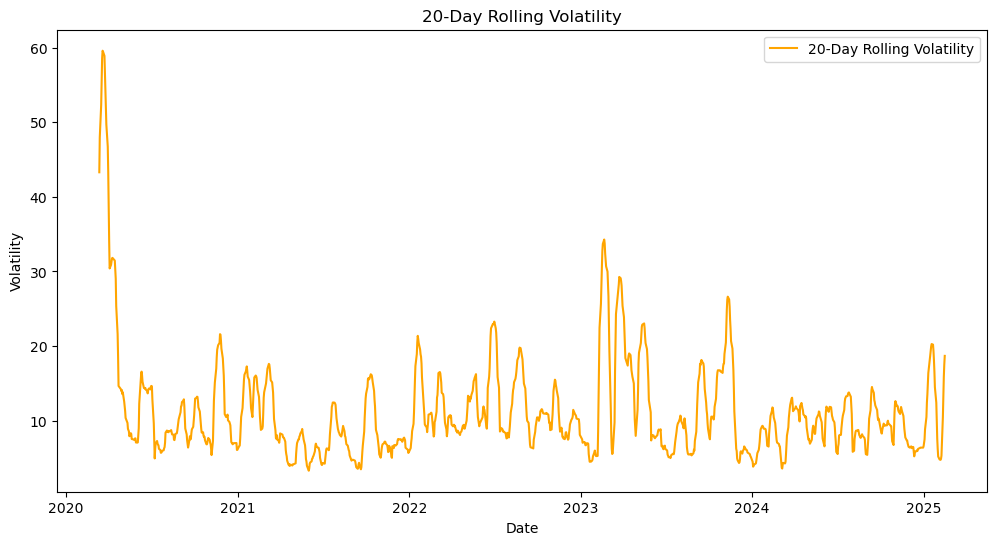

In [13]:
#Volitility Analysis
df['Volatility_20'] = df['Close'].rolling(window=20).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Volatility_20'], label='20-Day Rolling Volatility', color='orange')
plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.show()

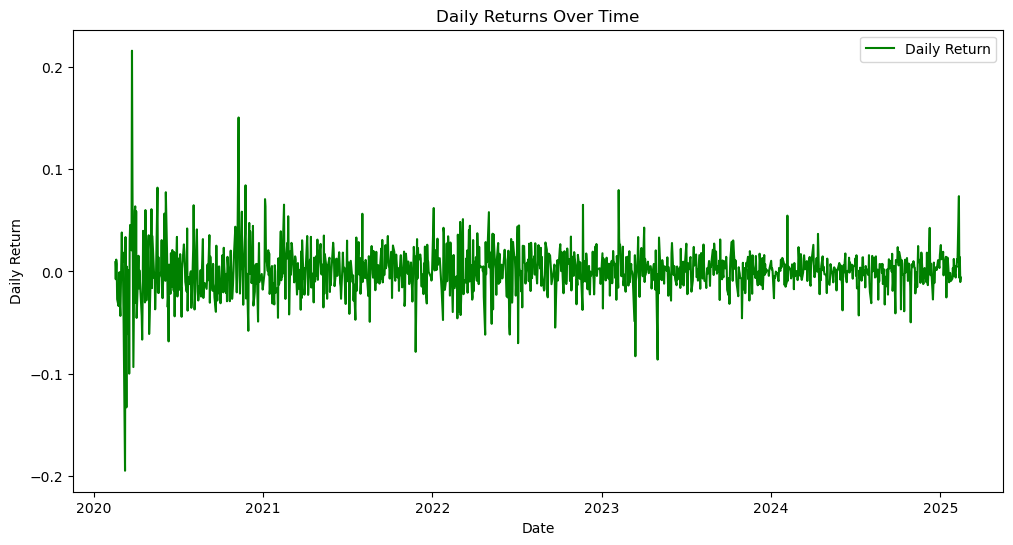

In [14]:
#Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(12, 6))
plt.plot(df['Daily_Return'], label='Daily Return', color='green')
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()

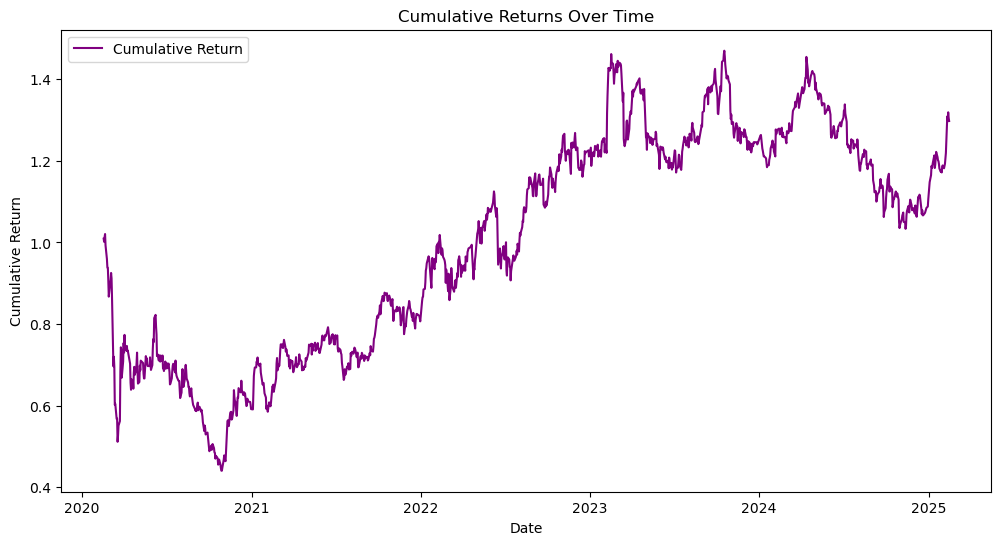

In [15]:
#Cumulative Returns
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(df['Cumulative_Return'], label='Cumulative Return', color='purple')
plt.title('Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()